# 10 · LoRA SFT End to End

**Hardware**: 🟡 24GB VRAM. A deliberately small task so the whole notebook runs in minutes.

## What you will do

1. Find out why a normal `target_modules` list **crashes** on Gemma 4 — and fix it
2. Confirm the KV-sharing consequence: 35 layers get `q_proj` adapters, only 15 get `k_proj`
3. Write a multimodal collator and mask labels correctly
4. Train a LoRA that changes the model's *output format*, and compare before/after
5. Read the memory arithmetic off the live model

In [1]:
%pip install -q "transformers>=5.14" accelerate peft torch pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Trainer auto-enables DataParallel when it sees more than one GPU, which replicates
# the whole model onto every card and OOMs a 24GB board. One device is what we want.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import random
import torch
from PIL import Image, ImageDraw
from transformers import (AutoModelForImageTextToText, AutoProcessor,
                          Trainer, TrainingArguments)
from peft import LoraConfig, get_peft_model

MODEL_ID = "google/gemma-4-E2B-it"
random.seed(0); torch.manual_seed(0)

processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="right")
processor.image_processor.max_soft_tokens = 70     # small images, small budget, fast steps

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map="cuda:0", attn_implementation="sdpa")
print(model.dtype, model.device)

/venv/main/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

Loading weights:   5%|▍         | 96/1951 [00:00<00:01, 931.79it/s]

Loading weights:  10%|▉         | 190/1951 [00:00<00:01, 891.33it/s]

Loading weights:  14%|█▍        | 280/1951 [00:00<00:01, 836.17it/s]

...

Loading weights:  73%|███████▎  | 1417/1951 [00:12<00:01, 486.17it/s]

Loading weights:  84%|████████▍ | 1648/1951 [00:12<00:00, 981.75it/s]

Loading weights:  96%|█████████▋| 1879/1951 [00:12<00:00, 1352.76it/s]

Loading weights: 100%|██████████| 1951/1951 [00:12<00:00, 152.54it/s] 

torch.bfloat16 cuda:0


**`padding_side="right"` here.** Left padding is for *generation* ([chapter 02](../../02-text-io/index.md) §6); during training there is no decode loop, and right padding keeps the label alignment obvious.

## 1. A task with a checkable answer

Coloured shapes, and a rigid output format. The base model will answer in prose; we want `SHAPE=circle;COLOR=red` and nothing else.

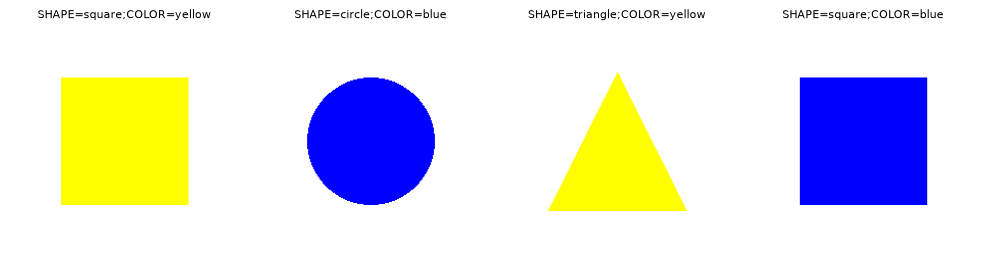

In [3]:
SHAPES = ["circle", "square", "triangle"]
COLOURS = ["red", "green", "blue", "yellow"]

def make_sample():
    shape, colour = random.choice(SHAPES), random.choice(COLOURS)
    im = Image.new("RGB", (224, 224), "white")
    d = ImageDraw.Draw(im)
    if shape == "circle":
        d.ellipse([50, 50, 174, 174], fill=colour)
    elif shape == "square":
        d.rectangle([50, 50, 174, 174], fill=colour)
    else:
        d.polygon([(112, 45), (45, 180), (180, 180)], fill=colour)
    return im, f"SHAPE={shape};COLOR={colour}"

PROMPT = "Identify the shape and colour."

train = [make_sample() for _ in range(96)]
held_out = [make_sample() for _ in range(4)]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(10, 2.6))
for ax, (im, lab) in zip(axes, train[:4]):
    ax.imshow(im); ax.axis("off"); ax.set_title(lab, fontsize=8)
plt.tight_layout(); plt.show()

## 2. Before

In [4]:
def predict(image, max_new_tokens=40):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image}, {"type": "text", "text": PROMPT}]}]
    gen_processor = AutoProcessor.from_pretrained(MODEL_ID, padding_side="left")
    gen_processor.image_processor.max_soft_tokens = 70
    inputs = gen_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return gen_processor.decode(out[0][input_len:], skip_special_tokens=True).strip()

print("BEFORE training:\n")
before = []
for im, gold in held_out:
    got = predict(im)
    before.append(got)
    print(f"  want: {gold}")
    print(f"  got : {got[:150]!r}\n")

BEFORE training:



  want: SHAPE=triangle;COLOR=blue
  got : 'The image displays a **triangle** that is **blue**.'



  want: SHAPE=square;COLOR=blue
  got : 'The image contains a **square** shape that is **blue**.'



  want: SHAPE=circle;COLOR=red
  got : 'The image displays a **circle** that is **red**.'



  want: SHAPE=square;COLOR=red
  got : 'The image displays a **square** shape that is **red** in color.'



## 3. The LoRA config, and the trap

The obvious config fails on Gemma 4. Run it and read the error.

In [5]:
naive = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, bias="none",
                   task_type="CAUSAL_LM",
                   target_modules=["q_proj", "k_proj", "v_proj", "o_proj"])
try:
    get_peft_model(model, naive)
except ValueError as e:
    print("ValueError:", str(e)[:300])

ValueError: Target module Gemma4ClippableLinear(
  (linear): Linear(in_features=768, out_features=768, bias=False)
) is not supported. Currently, only the following modules are supported: `torch.nn.Linear`, `torch.nn.Embedding`, `torch.nn.Conv1d`, `torch.nn.Conv2d`, `torch.nn.Conv3d`, `transformers.pytorch_util


A plain name list matches `q_proj` **inside the vision and audio towers too** — and those are `Gemma4ClippableLinear` wrappers ([chapter 04](../../04-vision-tower/index.md) §3), not `nn.Linear`, so PEFT cannot wrap them.

Scope the match to the language model with a regex:

In [6]:
lora = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    target_modules=r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj)$",
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

counts = {}
for name, _ in model.named_modules():
    if name.endswith("lora_A.default"):
        proj = name.split(".")[-3]
        counts[proj] = counts.get(proj, 0) + 1
print("\nadapters per projection:", counts)

trainable params: 2,678,784 || all params: 5,106,976,288 || trainable%: 0.0525

adapters per projection: {'q_proj': 35, 'k_proj': 15, 'v_proj': 15, 'o_proj': 35}


**Read those counts.** 35 `q_proj` and `o_proj` adapters, but only 15 `k_proj` and `v_proj` — because layers 15–34 are KV-shared and **own no key or value projections at all** ([chapter 06](../../06-text-decoder/index.md) §4). There is nothing there to adapt.

Nobody tells you this. `print_trainable_parameters()` just reports a smaller number than you predicted, and you shrug.

## 4. The collator

Four requirements, each from an earlier chapter.

In [7]:
MASK_TOKENS = {model.config.image_token_id, model.config.audio_token_id,
               model.config.video_token_id, model.config.boi_token_id,
               model.config.eoi_token_id}
RESPONSE_MARKER = processor.tokenizer.encode("<|turn>model\n", add_special_tokens=False)


def collate(batch):
    texts, images = [], []
    for image, answer in batch:
        messages = [
            {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": PROMPT}]},
            {"role": "assistant", "content": [{"type": "text", "text": answer}]},
        ]
        # tokenize=False: the template emits ONE <|image|>; only the processor
        # knows how many soft tokens the image is worth (chapter 02 §2)
        texts.append(processor.apply_chat_template(messages, tokenize=False,
                                                   add_generation_prompt=False))
        images.append([image])                      # nested: one list per sample

    out = processor(text=texts, images=images, return_tensors="pt", padding=True)

    labels = out["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    for tid in MASK_TOKENS:
        labels[labels == tid] = -100

    # train on the response only: mask everything up to and including the final
    # "<|turn>model\n" marker
    ids = out["input_ids"]
    for row in range(ids.shape[0]):
        seq = ids[row].tolist()
        cut = 0
        for i in range(len(seq) - len(RESPONSE_MARKER), -1, -1):
            if seq[i:i + len(RESPONSE_MARKER)] == RESPONSE_MARKER:
                cut = i + len(RESPONSE_MARKER)
                break
        labels[row, :cut] = -100

    out["labels"] = labels
    return out

In [8]:
# Sanity check: decode exactly what the loss will see. Do this every time.
sample = collate(train[:2])
for row in range(2):
    kept = sample["labels"][row][sample["labels"][row] != -100]
    print(f"row {row} supervised tokens -> {processor.tokenizer.decode(kept)!r}")

print(f"\nsupervised / total: {int((sample['labels'] != -100).sum())} / {sample['labels'].numel()}")
print("If that is not exactly the assistant's answer, stop and fix the collator.")

row 0 supervised tokens -> 'SHAPE=square;COLOR=yellow<turn|>\n'
row 1 supervised tokens -> 'SHAPE=circle;COLOR=blue<turn|>\n'

supervised / total: 20 / 182
If that is not exactly the assistant's answer, stop and fix the collator.


## 5. Memory arithmetic, before launching

In [9]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
bytes_bf16 = 2

print(f"frozen weights   : {frozen/1e9:6.2f}B  ~ {frozen*bytes_bf16/1e9:5.2f} GB")
print(f"trainable (LoRA) : {trainable/1e6:6.2f}M  ~ {trainable*bytes_bf16/1e6:5.1f} MB")
print(f"gradients        : {trainable*bytes_bf16/1e6:5.1f} MB   (adapters only)")
print(f"AdamW state (fp32 x2): {trainable*8/1e6:5.1f} MB")
print("\nActivations are the variable you control: batch_size x sequence_length.")
print(f"One sample here is ~{sample['input_ids'].shape[-1]} tokens "
      f"({int((sample['input_ids'][0] == model.config.image_token_id).sum())} of them the image).")
print("At max_soft_tokens=280 the image alone would be 4x that.")
print(f"\nGPU allocated now: {torch.cuda.memory_allocated()/1e9:.2f} GB")

frozen weights   :   5.10B  ~ 10.21 GB
trainable (LoRA) :   2.68M  ~   5.4 MB
gradients        :   5.4 MB   (adapters only)
AdamW state (fp32 x2):  21.4 MB

Activations are the variable you control: batch_size x sequence_length.
One sample here is ~91 tokens (64 of them the image).
At max_soft_tokens=280 the image alone would be 4x that.

GPU allocated now: 10.23 GB


## 6. Train

In [10]:
args = TrainingArguments(
    output_dir="lora-shapes",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=5,
    save_strategy="no",
    report_to=[],
    remove_unused_columns=False,     # REQUIRED: Trainer would strip pixel_values
)

trainer = Trainer(model=model, args=args, train_dataset=train, data_collator=collate)
model.config.use_cache = False
result = trainer.train()
model.config.use_cache = True
print(f"\nfinal train loss: {result.training_loss:.4f}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[RANK 0] Detected kernel version 4.15.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Step,Training Loss
5,6.897802
10,3.211094
15,0.739020
20,0.032132
25,0.001086
30,0.000339
35,0.000275



final train loss: 1.5114


`remove_unused_columns=False` is not optional. `Trainer` inspects `forward`'s signature and drops dataset columns it does not recognise. With a custom collator producing `pixel_values` and `image_position_ids`, the default silently removes them — and you train a text-only model on prompts full of pad embeddings, with **no error at all**.

## 7. After

In [11]:
model.eval()
print("AFTER training:\n")
hits = 0
for (im, gold), was in zip(held_out, before):
    got = predict(im)
    ok = got.strip() == gold
    hits += ok
    print(f"  want   : {gold}")
    print(f"  before : {was[:70]!r}")
    print(f"  after  : {got[:70]!r}   {'OK' if ok else 'x'}\n")
print(f"exact-format matches on held-out: {hits}/{len(held_out)}")

AFTER training:



  want   : SHAPE=triangle;COLOR=blue
  before : 'The image displays a **triangle** that is **blue**.'
  after  : 'SHAPE=triangle;COLOR=blue'   OK



  want   : SHAPE=square;COLOR=blue
  before : 'The image contains a **square** shape that is **blue**.'
  after  : 'SHAPE=square;COLOR=blue'   OK



  want   : SHAPE=circle;COLOR=red
  before : 'The image displays a **circle** that is **red**.'
  after  : 'SHAPE=circle;COLOR=red'   OK



  want   : SHAPE=square;COLOR=red
  before : 'The image displays a **square** shape that is **red** in color.'
  after  : 'SHAPE=square;COLOR=red'   OK

exact-format matches on held-out: 4/4


In [12]:
# Adapters are tiny and portable
model.save_pretrained("lora-shapes/adapter")
import os
size = sum(os.path.getsize(os.path.join(dp, f))
           for dp, _, fs in os.walk("lora-shapes/adapter") for f in fs)
print("saved files:", sorted(os.listdir("lora-shapes/adapter")))
print(f"adapter size: {size/1e6:.1f} MB  (against a {10.25:.2f} GB base checkpoint)")

saved files: ['README.md', 'adapter_config.json', 'adapter_model.safetensors']
adapter size: 10.8 MB  (against a 10.25 GB base checkpoint)


## Exercises

1. Add `"gate_proj"`, `"up_proj"`, `"down_proj"` to the regex. How many more adapters, and does the format lock in faster?
2. Add `embedding_projection` (the connector, [chapter 04](../../04-vision-tower/index.md) §5) to the targets. Does adapting *where visual features land* help this task?
3. Remove the response-only masking and retrain. Watch the model start generating the prompt back.
4. Set `remove_unused_columns=True` and retrain. Does it error? What does the loss do? This is the failure mode to internalise.
5. Raise `max_soft_tokens` to 280 and re-measure peak memory. How does activation memory scale with the image budget?
6. Introduce a shape the model has never seen (a star). Does the LoRA generalise the *format* to it even when the label is wrong?
7. Unfreeze the vision tower with a 10x lower learning rate. Does this task benefit, and what does it cost in memory?

## Where next

That closes Part I. [Part II](../../20-image-generation/index.md) runs the arrow the other way — text in, pixels and sound out.